# **KHAI PHÁ DỮ LIỆU - SUPPORT VECTOR MACHINE**

In [2]:
!gdown --id "1f8acuoB6uyUuzIITr8nfpySbQkpvMuaY"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1f8acuoB6uyUuzIITr8nfpySbQkpvMuaY
To: /content/diabetes.csv
100% 23.9k/23.9k [00:00<00:00, 38.6MB/s]


# **MÔI TRƯỜNG LẬP TRÌNH**

In [3]:
# Thư viện sử dụng
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC                         # Cho SVM
from sklearn.linear_model import LogisticRegression # Cho Logistic Regression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Đọc tập tin dữ liệu
file = r'diabetes.csv'
raw_df = pd.read_csv(file)
df = raw_df.copy()
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **THĂM DÒ DỮ LIỆU (EXPLORATORY DATA ANALYSIS - EDA)**

##***1.1. Giới thiệu bộ dữ liệu***

In [5]:
vn_cols = {
    'Pregnancies': 'Số lần mang thai',
    'Glucose': 'Nồng độ Glucose (Huyết tương)',
    'BloodPressure': 'Huyết áp tâm trương (mm Hg)',
    'SkinThickness': 'Độ dày nếp gấp da (mm)',
    'Insulin': 'Nồng độ Insulin (mu U/ml)',
    'BMI': 'Chỉ số khối cơ thể (BMI)',
    'DiabetesPedigreeFunction': 'Chức năng phả hệ tiểu đường (Di truyền)',
    'Age': 'Tuổi',
    'Outcome': 'Kết quả (0: Không, 1: Có bệnh)'
}

df_mapping = pd.DataFrame(list(vn_cols.items()), columns=['Tên biến (English)', 'Tên biến (Tiếng Việt)'])
display(df_mapping)

,Tên biến (English),Tên biến (Tiếng Việt)
0,Pregnancies,Số lần mang thai
1,Glucose,Nồng độ Glucose (Huyết tương)
2,BloodPressure,Huyết áp tâm trương (mm Hg)
3,SkinThickness,Độ dày nếp gấp da (mm)
4,Insulin,Nồng độ Insulin (mu U/ml)
5,BMI,Chỉ số khối cơ thể (BMI)
6,DiabetesPedigreeFunction,Chức năng phả hệ tiểu đường (Di truyền)
7,Age,Tuổi
8,Outcome,"Kết quả (0: Không, 1: Có bệnh)"


In [6]:
# Metadata
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# Thống kê mô tả
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# Kiểm tra Dimension
num_rows, num_columns = df.shape
print(f'Dữ liệu có {num_rows} quan sát và {num_columns} cột thuộc tính')

Dữ liệu có 768 quan sát và 9 cột thuộc tính


In [9]:
# Cấu trúc dữ liệu
def properties_chk(dataframe):
    dataframe_check = pd.DataFrame({
        'Số lượng quan sát (Count)': dataframe.count(),
        'Số giá trị khác nhau (Unique)': dataframe.nunique(),
        'Kiểu dữ liệu (Dtype)': dataframe.dtypes,
        'Số lượng Null': dataframe.isnull().sum()
    })
    return dataframe_check

In [10]:
properties_chk(df)

,Số lượng quan sát (Count),Số giá trị khác nhau (Unique),Kiểu dữ liệu (Dtype),Số lượng Null
Pregnancies,768,17,int64,0
Glucose,768,136,int64,0
BloodPressure,768,47,int64,0
SkinThickness,768,51,int64,0
Insulin,768,186,int64,0
BMI,768,248,float64,0
DiabetesPedigreeFunction,768,517,float64,0
Age,768,52,int64,0
Outcome,768,2,int64,0


## **2.2 Kiểm tra chất lượng**

### **2.2.1. Kiểm tra giá trị rỗng (null)**

In [11]:
# Kiểm tra giá trị rỗng, null
def null_chk(dataframe):
    dataframe_check = pd.DataFrame({
        'Số quan sát': dataframe.count(),
        'Số giá trị rỗng': dataframe.isnull().sum(),
        'Phần trăm rỗng': (dataframe.isnull().sum() / len(dataframe)) * 100
    })
    dataframe_check['Phần trăm rỗng'] = dataframe_check['Phần trăm rỗng'].map('{:.2f}%'.format)
    return dataframe_check.style

In [12]:
null_chk(df)

,Số quan sát,Số giá trị rỗng,Phần trăm rỗng
Pregnancies,768,0,0.00%
Glucose,768,0,0.00%
BloodPressure,768,0,0.00%
SkinThickness,768,0,0.00%
Insulin,768,0,0.00%
BMI,768,0,0.00%
DiabetesPedigreeFunction,768,0,0.00%
Age,768,0,0.00%
Outcome,768,0,0.00%


### **2.2.2. Kiểm tra trùng lặp**


In [13]:
duplicated_df = df[df.duplicated()]
duplicated_df = df[df.duplicated(subset=['Pregnancies', 'Glucose',
                                         'BloodPressure', 'SkinThickness',
                                         'Insulin', 'BMI',
                                         'DiabetesPedigreeFunction',
                                         'Age', 'Outcome'])]

print(f"Số dòng trùng lặp: {len(duplicated_df)}")
duplicated_df

Số dòng trùng lặp: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


### **2.2.3. Kiểm tra giá trị thiếu**

In [14]:
# Hiển thị thông tin
print("\nThông tin missing values:")
print(df.isnull().sum())
print("\nTỷ lệ missing (%):")
print(df.isnull().sum() / len(df) * 100)


Thông tin missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Tỷ lệ missing (%):
Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64


In [15]:
print("Mục đích: Thống kê tỷ lệ giá trị 0 (dữ liệu khuyết ẩn) trên các chỉ số lâm sàng quan trọng")
cols_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
results = []
for col in cols_check:
    count = (df[col] == 0).sum()
    percent = (count / len(df)) * 100
    if count > 0:
        results.append({
            'Tên biến (Attribute)': col,
            'Số lượng giá trị 0': count,
            'Tỷ lệ lỗi (%)': percent,
            'Đánh giá': 'Nghiêm trọng' if percent > 30 else 'Trung bình' if percent > 5 else 'Thấp'
        })
df_missing = pd.DataFrame(results)
df_missing = df_missing.sort_values(by='Tỷ lệ lỗi (%)', ascending=False)
display(
    df_missing.style
    .format({'Tỷ lệ lỗi (%)': '{:.2f}%'})
    .background_gradient(cmap='Reds', subset=['Tỷ lệ lỗi (%)'])
    .set_properties(**{'text-align': 'left'})
)

Mục đích: Thống kê tỷ lệ giá trị 0 (dữ liệu khuyết ẩn) trên các chỉ số lâm sàng quan trọng


,Tên biến (Attribute),Số lượng giá trị 0,Tỷ lệ lỗi (%),Đánh giá
3,Insulin,374,48.70%,Nghiêm trọng
2,SkinThickness,227,29.56%,Trung bình
1,BloodPressure,35,4.56%,Thấp
4,BMI,11,1.43%,Thấp
0,Glucose,5,0.65%,Thấp


## **2.3. Trực quan hóa dữ liệu**

### **2.3.1. Phân bố biến mục tiêu**

In [16]:
# Biến mục tiêu
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


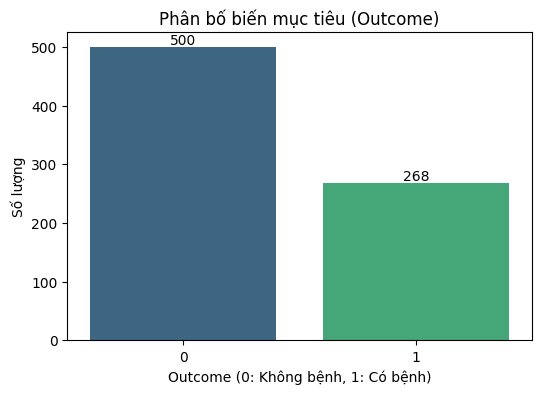

In [17]:
# Biểu đồ phân bố biến mục tiêu
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=df, hue='Outcome', palette="viridis", legend=False)
plt.title('Phân bố biến mục tiêu (Outcome)')
plt.xlabel('Outcome (0: Không bệnh, 1: Có bệnh)')
plt.ylabel('Số lượng')
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [18]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


### **2.3.2. Phân phối và Mối quan hệ của các biến đặc trưng**

#### **2.3.2.1. Khám phá biến Pregnancies**

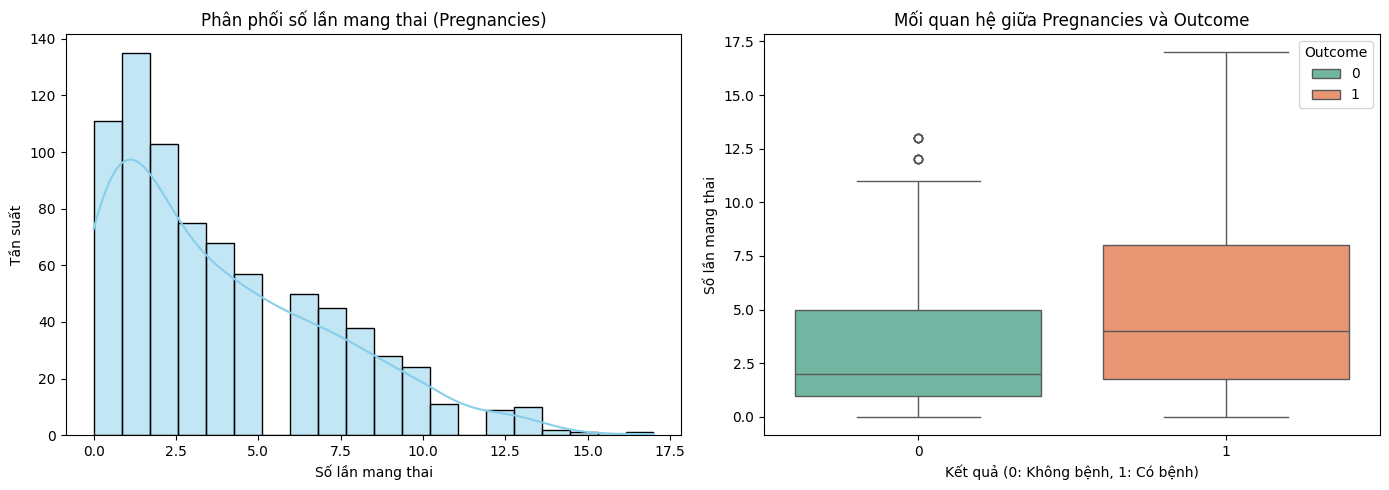

In [19]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['Pregnancies'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối số lần mang thai (Pregnancies)')
axes[0].set_xlabel('Số lần mang thai')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='Pregnancies', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa Pregnancies và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('Số lần mang thai')

plt.tight_layout()
plt.show()

#### **2.3.2.2. Khám phá biến Glucose**

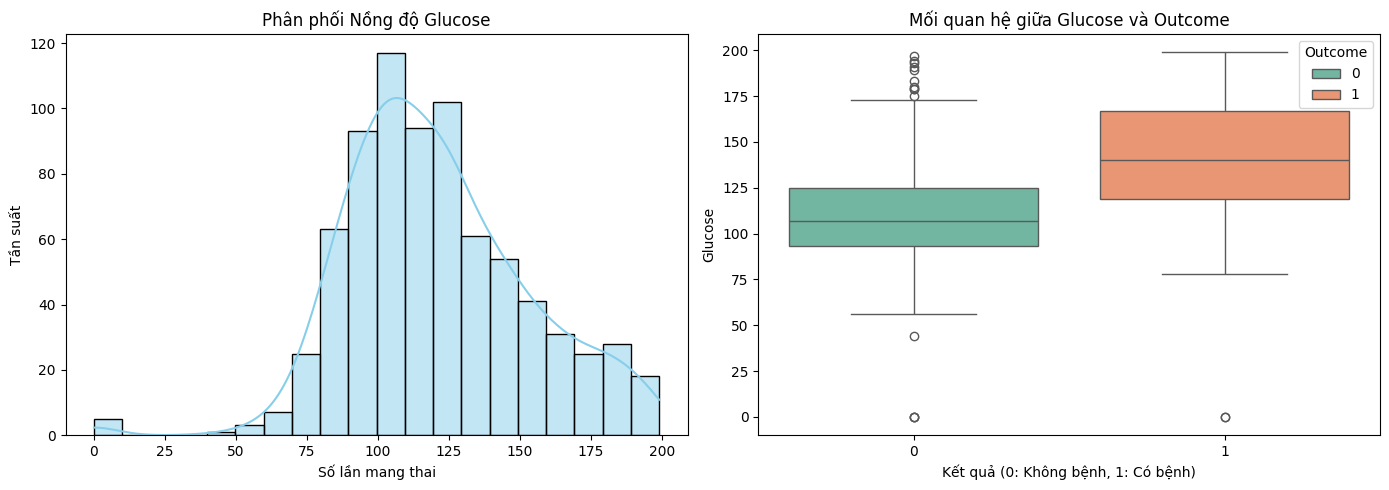

In [20]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['Glucose'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Nồng độ Glucose')
axes[0].set_xlabel('Số lần mang thai')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa Glucose và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('Glucose')

plt.tight_layout()
plt.show()

#### **2.3.2.3. Khám phá biến BloodPressure**

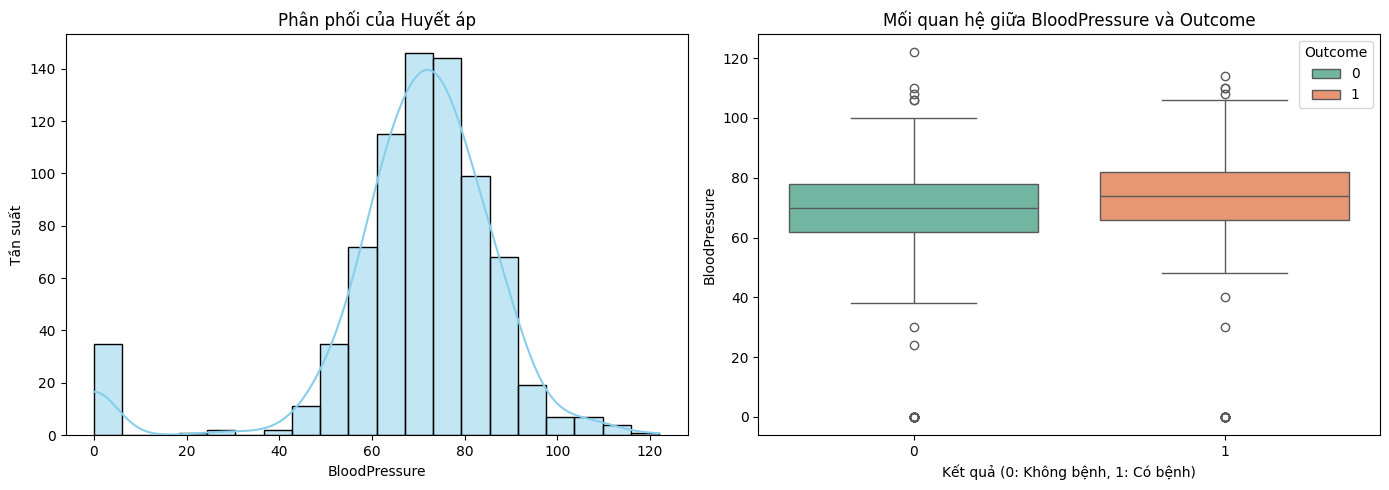

In [22]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['BloodPressure'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Huyết áp')
axes[0].set_xlabel('BloodPressure')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='BloodPressure', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa BloodPressure và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('BloodPressure')

plt.tight_layout()
plt.show()

#### **2.3.2.4. Khám phá biến SkinThickness**

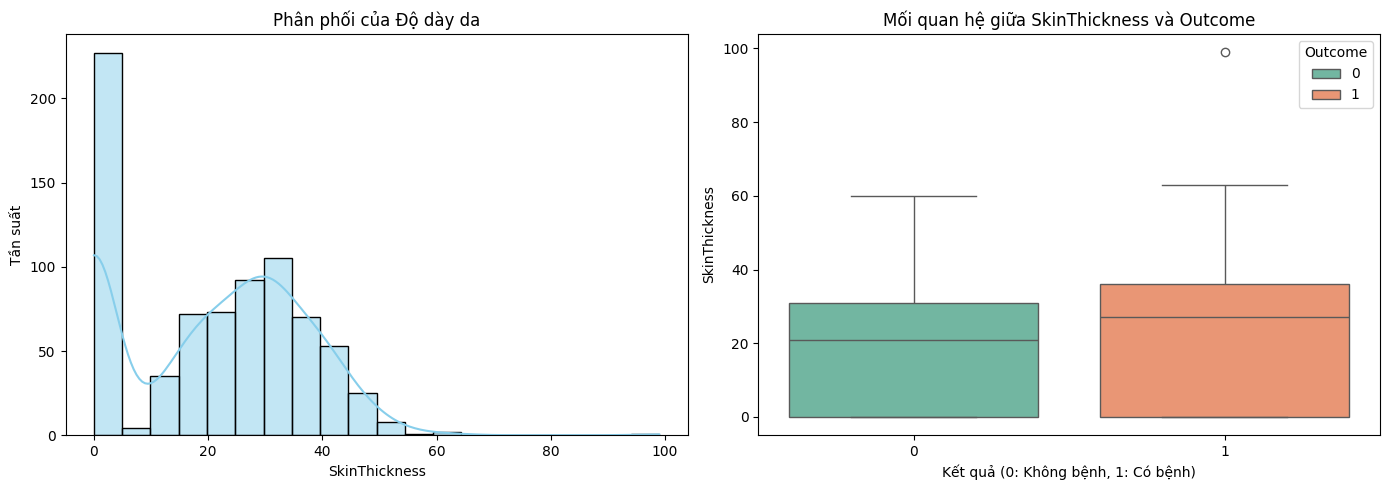

In [23]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['SkinThickness'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Độ dày da')
axes[0].set_xlabel('SkinThickness')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='SkinThickness', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa SkinThickness và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('SkinThickness')

plt.tight_layout()
plt.show()

#### **2.3.2.5. Khám phá biến Insulin**

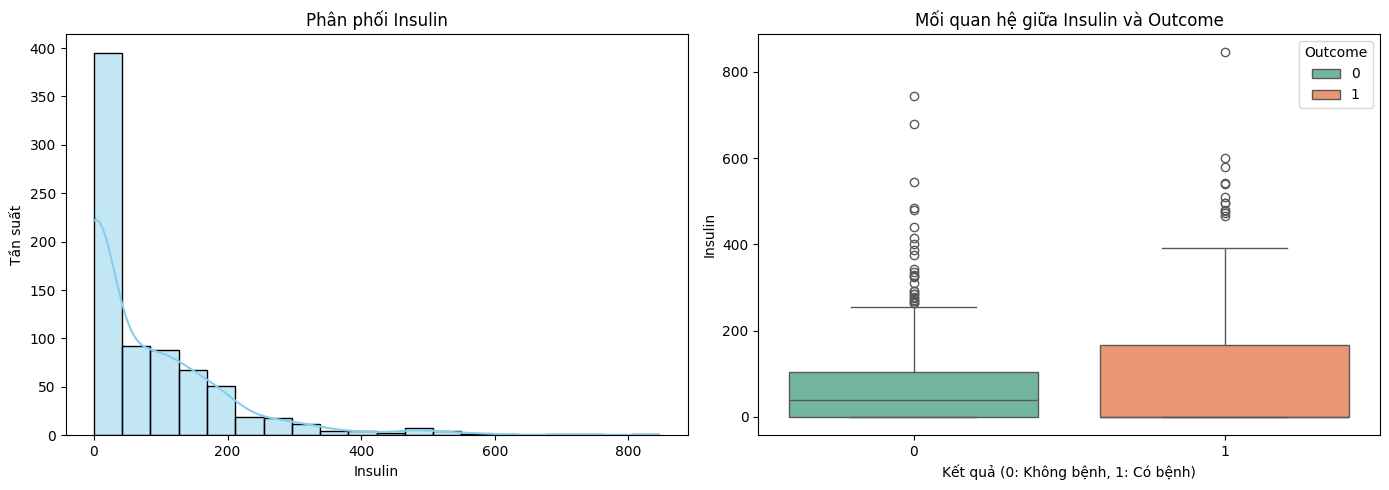

In [24]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['Insulin'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Insulin')
axes[0].set_xlabel('Insulin')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='Insulin', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa Insulin và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('Insulin')

plt.tight_layout()
plt.show()

#### **2.3.2.6. Khám phá biến BMI**

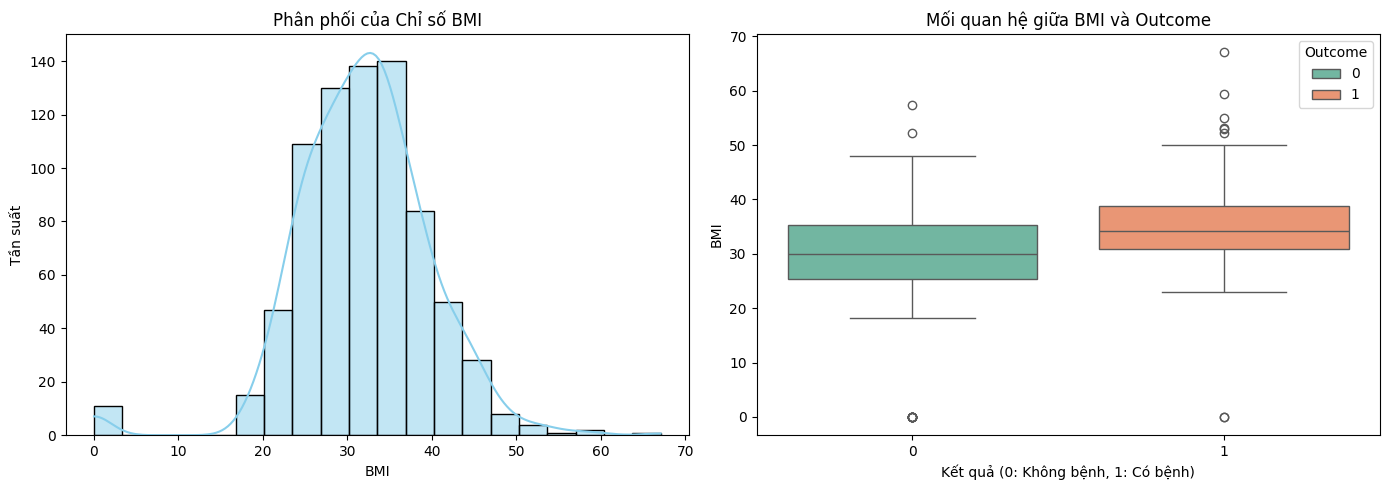

In [25]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['BMI'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Chỉ số BMI')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa BMI và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('BMI')

plt.tight_layout()
plt.show()

#### **2.3.2.7. Khám phá biến DiabetesPedigreeFunction**

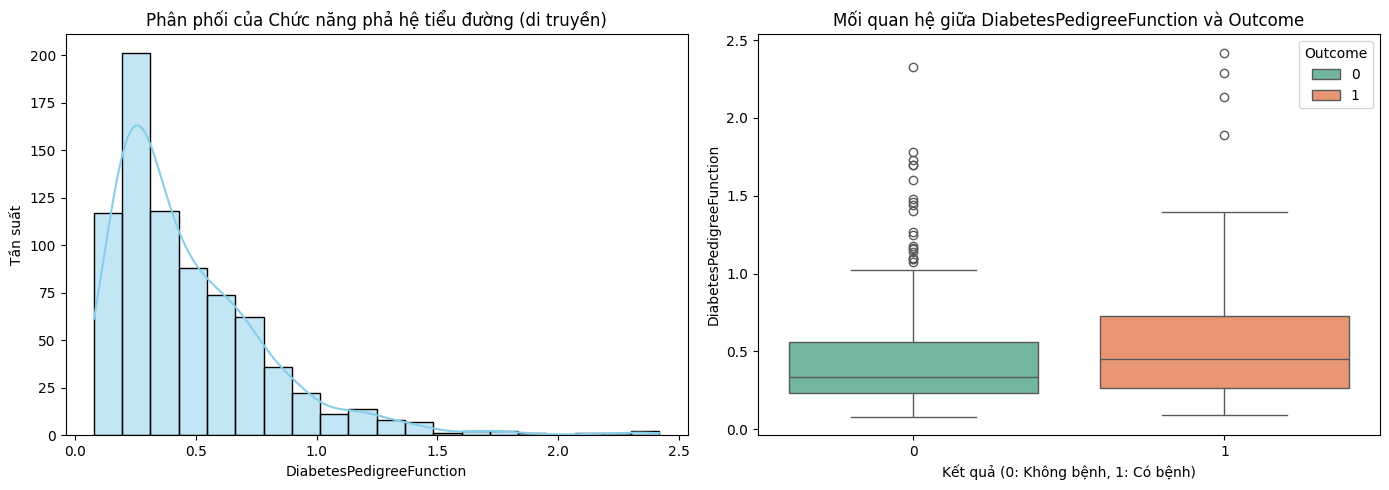

In [26]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['DiabetesPedigreeFunction'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Chức năng phả hệ tiểu đường (di truyền)')
axes[0].set_xlabel('DiabetesPedigreeFunction')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa DiabetesPedigreeFunction và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('DiabetesPedigreeFunction')

plt.tight_layout()
plt.show()

#### **2.3.2.8. Khám phá biến Age**

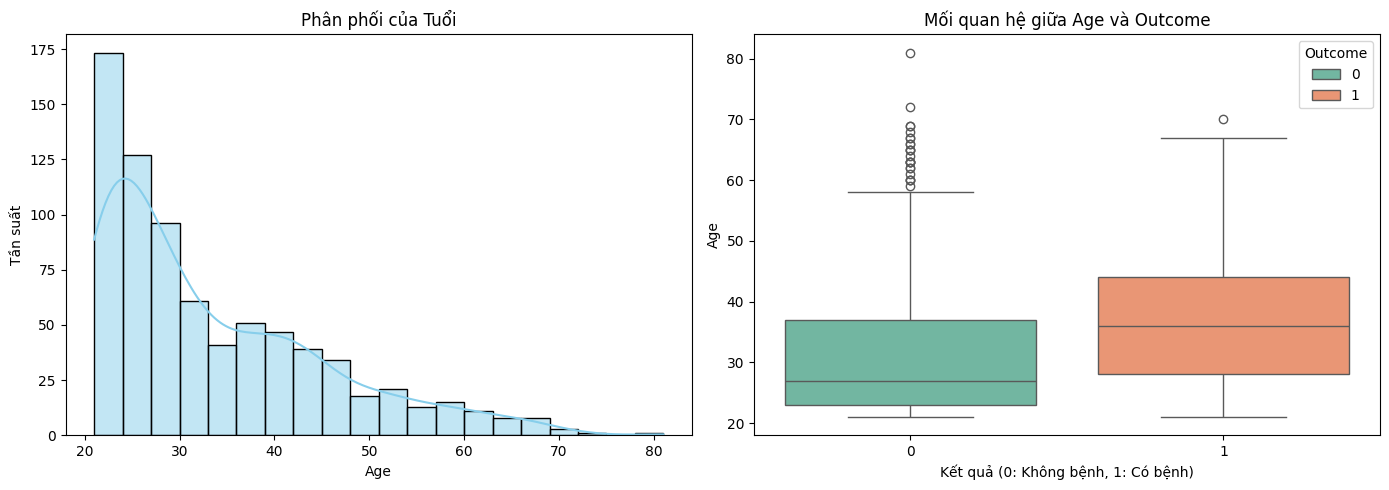

In [27]:
# Tạo khung hình với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (Biểu đồ phân phối)
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Tuổi')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Tần suất')

# Boxplot (Biểu đồ hộp) so sánh với Outcome
sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[1], hue='Outcome', palette='Set2')
axes[1].set_title('Mối quan hệ giữa Age và Outcome')
axes[1].set_xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

### **2.3.3. Tương quan biến số**

In [28]:
# Tính toán ma trận tương quan
corr_matrix = df.corr()

In [29]:
print("\n-- HỆ SỐ TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (OUTCOME) --")
print(corr_matrix['Outcome'].sort_values(ascending=False))


-- HỆ SỐ TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (OUTCOME) --
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


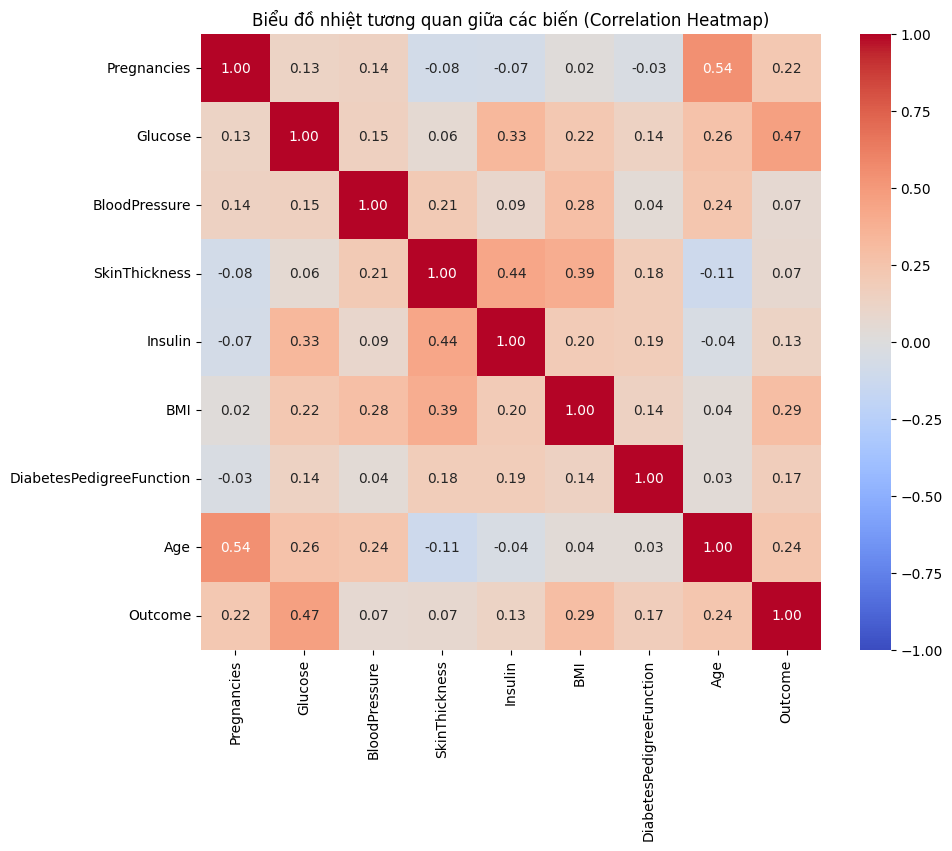

In [30]:
# Biểu đồ nhiệt
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Biểu đồ nhiệt tương quan giữa các biến (Correlation Heatmap)')
plt.show()

# **TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)**


## **3.1. Xử lý dữ liệu thiếu**

In [31]:
# 1. Chuyển đổi số 0 thành NaN
cols_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_missing] = df[cols_missing].replace(0, np.nan)
# Kiểm tra lại số lượng NaN
print("Số lượng NaN trước khi xử lý:")
print(df[cols_missing].isnull().sum())

Số lượng NaN trước khi xử lý:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [32]:
df_before = df.copy()

for col in cols_missing:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"-> Đã điền cột {col} bằng Median: {median_val}")

-> Đã điền cột Glucose bằng Median: 117.0
-> Đã điền cột BloodPressure bằng Median: 72.0
-> Đã điền cột SkinThickness bằng Median: 29.0
-> Đã điền cột Insulin bằng Median: 125.0
-> Đã điền cột BMI bằng Median: 32.3


/tmp/ipykernel_6769/3689838711.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


## **3.2. Xử lý giá trị ngoại lai**

In [33]:
# Hàm xử lý ngoại lai bằng IQR Capping
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR     # Xác định biên
    upper_bound = Q3 + 1.5 * IQR
    # Thay thế giá trị vượt ngưỡng (Capping)
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data
cols_outlier = ['Insulin', 'DiabetesPedigreeFunction', 'BMI', 'Age', 'BloodPressure']
df_before = df.copy() # Lưu dữ liệu trước khi xử lý để so sánh
for col in cols_outlier: # Áp dụng Capping
    df = detect_outliers_iqr(df, col)

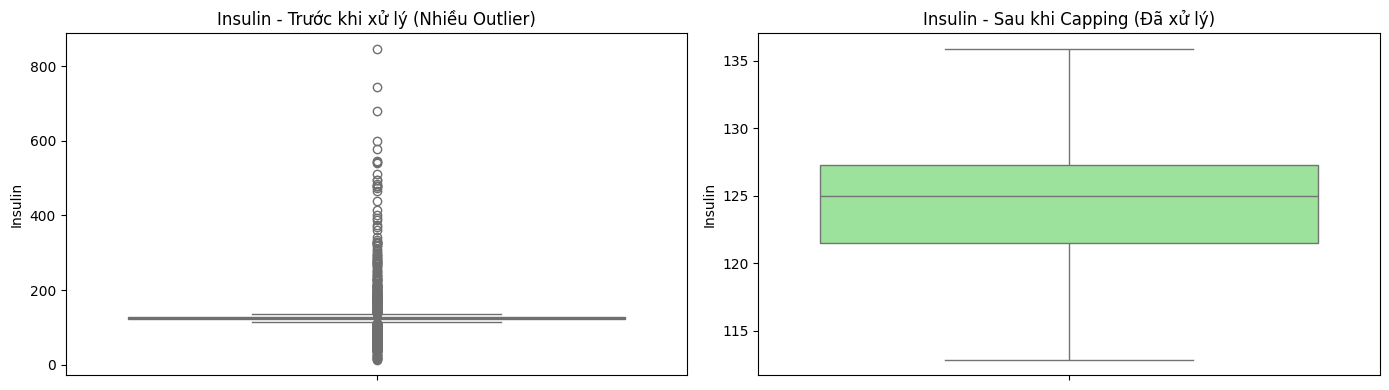

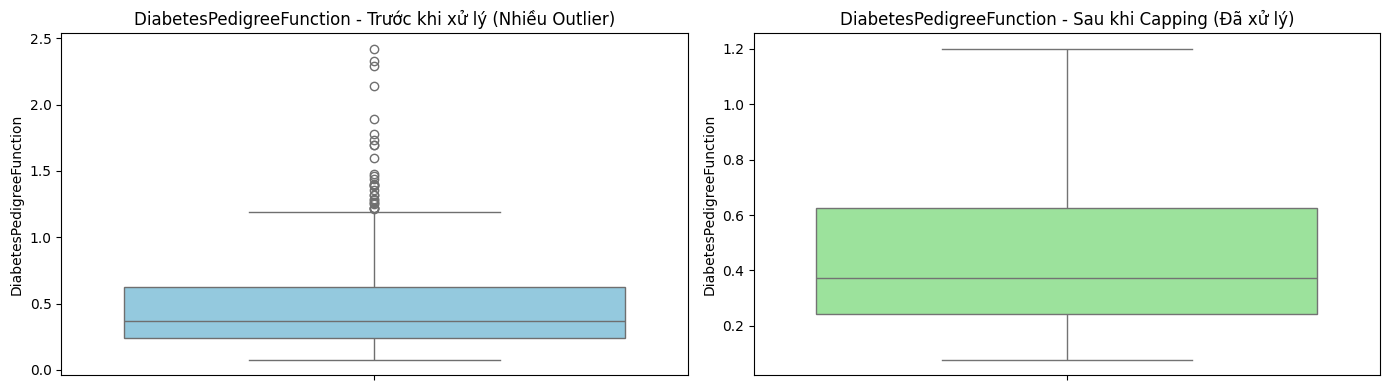

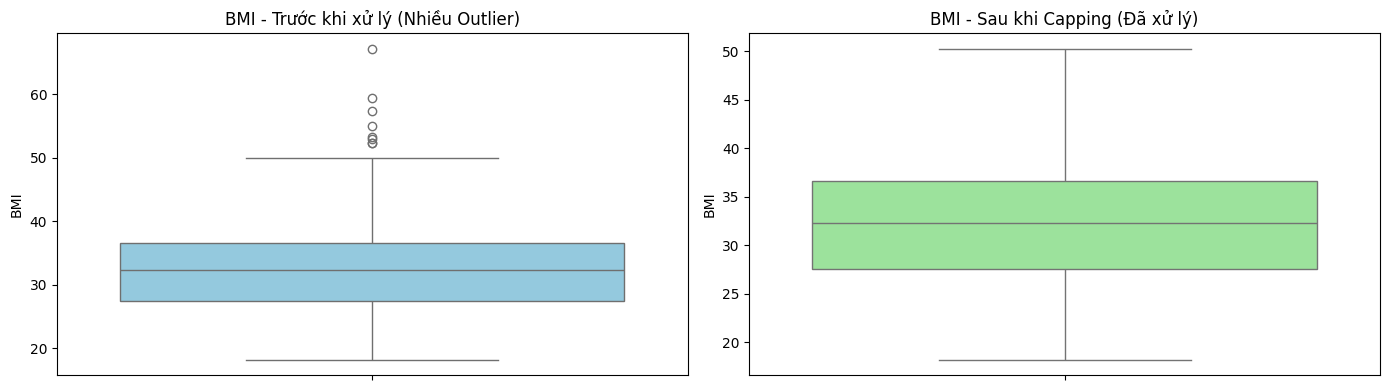

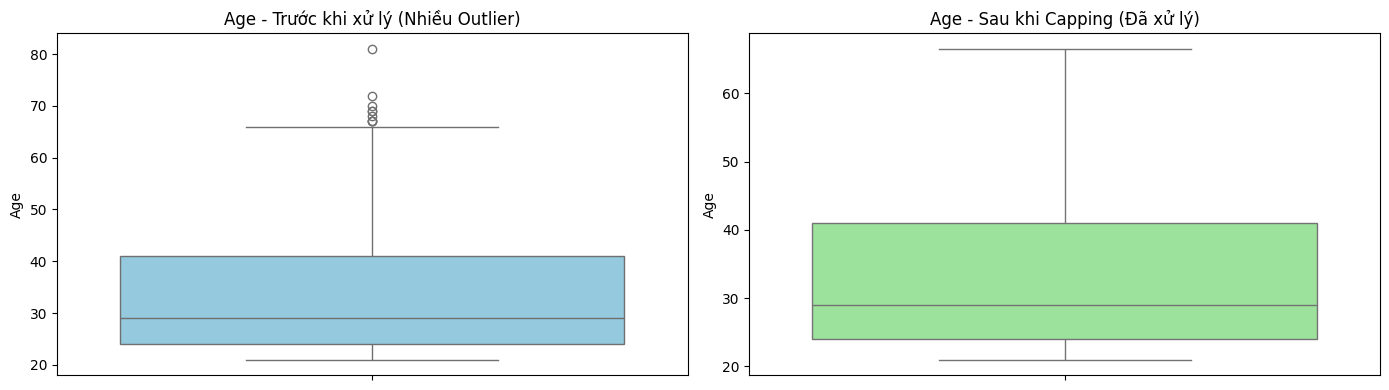

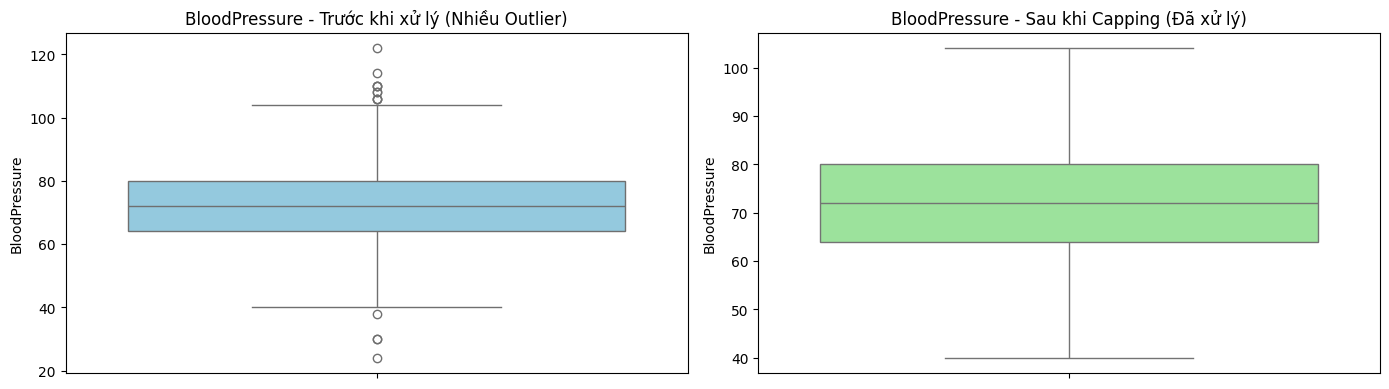


--- BẢNG SO SÁNH GIÁ TRỊ MAX ---


,Max Trước,Max Sau
Insulin,846.00,135.875
DiabetesPedigreeFunction,2.42,1.200
BMI,67.10,50.250
Age,81.00,66.500
BloodPressure,122.00,104.000


In [34]:
# TRỰC QUAN HÓA SO SÁNH TRƯỚC VÀ SAU KHI XỬ LÝ OUTLIER
# Danh sách các biến đã xử lý
cols_outlier = ['Insulin', 'DiabetesPedigreeFunction', 'BMI', 'Age', 'BloodPressure']
for col in cols_outlier: # Vòng lặp vẽ biểu đồ cho từng biến
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Biểu đồ Trước khi xử lý
    sns.boxplot(y=df_before[col], ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} - Trước khi xử lý (Nhiều Outlier)')
    # Biểu đồ Sau khi xử lý
    sns.boxplot(y=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'{col} - Sau khi Capping (Đã xử lý)')
    plt.tight_layout()
    plt.show()
# In bảng so sánh giá trị Max để thấy sự thay đổi rõ ràng
print("\n--- BẢNG SO SÁNH GIÁ TRỊ MAX ---")
comparison = pd.DataFrame({
    'Max Trước': df_before[cols_outlier].max(),
    'Max Sau': df[cols_outlier].max()
})
display(comparison)

## **3.3. Mã hóa dữ liệu**

In [35]:
data_types = df.dtypes
non_numeric_cols = df.select_dtypes(exclude=['number']).columns

print("Kiểu dữ liệu của từng cột:")
print(data_types)

print(f"\nDanh sách các cột không phải dạng số: {list(non_numeric_cols)}")

if len(non_numeric_cols) == 0:
    print("\n=> KẾT LUẬN: Toàn bộ dữ liệu đã ở dạng số học (Numerical).")
    print("=> KHÔNG CẦN thực hiện One-Hot Encoding hay Label Encoding.")
else:
    print(f"=> Cần mã hóa các cột: {list(non_numeric_cols)}")

Kiểu dữ liệu của từng cột:
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

Danh sách các cột không phải dạng số: []

=> KẾT LUẬN: Toàn bộ dữ liệu đã ở dạng số học (Numerical).
=> KHÔNG CẦN thực hiện One-Hot Encoding hay Label Encoding.


# **XÂY DỰNG & ĐÁNH GIÁ MÔ HÌNH CƠ SỞ**

## **4.1. Thiết lập mô hình**

In [36]:
X = df.drop('Outcome', axis=1) #X: Chứa các thông tin đầu vào (Số lần mang thai, Glucose,...)
y = df['Outcome'] # Y: Chứa đáp án (Có bệnh/Không bệnh)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")
feature_names = X.columns
# Mã hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Kích thước tập Train: (614, 8)
Kích thước tập Test: (154, 8)


In [37]:
# Khởi tạo mô hình
svm_linear = SVC(kernel='linear', random_state=42)

In [38]:
# Huấn luyện mô hình
svm_linear.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [39]:
# Dự đoán trên tập kiểm thử
y_pred = svm_linear.predict(X_test_scaled)

In [40]:
# Tính độ chính xác tổng thể
acc = accuracy_score(y_test, y_pred)
print(f"Độ chính xác tổng thể (Accuracy): {acc:.4f}")

Độ chính xác tổng thể (Accuracy): 0.7078


## **4.2. Kết quả thực nghiệm**

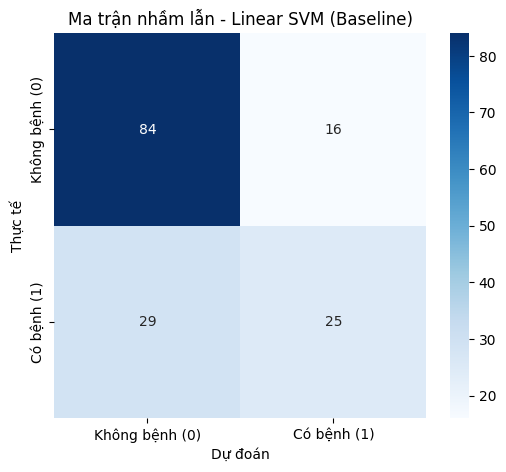

In [41]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'])
plt.title('Ma trận nhầm lẫn - Linear SVM (Baseline)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [42]:
# Tạo bảng báo cáo đầy đủ
print("Bảng báo cáo phân loại (Classification Report):")
print(classification_report(y_test, y_pred))

Bảng báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

           0       0.74      0.84      0.79       100
           1       0.61      0.46      0.53        54

    accuracy                           0.71       154
   macro avg       0.68      0.65      0.66       154
weighted avg       0.70      0.71      0.70       154



##**4.3. Phân tích sâu (Recall/Precision hiện tại)**

In [44]:
# Phân tích cụ thể các chỉ số quan trọng lớp có bệnh
report = classification_report(y_test, y_pred, output_dict=True)
precision_1 = report['1']['precision']
recall_1 = report['1']['recall']

In [45]:
print("\n--- ĐÁNH GIÁ CHI TIẾT ---")
print(f"1. Precision (Độ chính xác): {precision_1:.4f}")
print(f"   -> Ý nghĩa: Khi mô hình báo một người bị bệnh, có {precision_1*100:.1f}% khả năng là đúng.")

print(f"2. Recall (Độ nhạy): {recall_1:.4f}")
print(f"   -> Ý nghĩa: Mô hình chỉ phát hiện được {recall_1*100:.1f}% số lượng bệnh nhân thực tế.")
print(f"   -> Kết luận: Recall {recall_1*100:.1f}% là mức TRUNG BÌNH/THẤP. Mô hình đang bỏ sót tới {100 - recall_1*100:.1f}% bệnh nhân.")


--- ĐÁNH GIÁ CHI TIẾT ---
1. Precision (Độ chính xác): 0.6098
   -> Ý nghĩa: Khi mô hình báo một người bị bệnh, có 61.0% khả năng là đúng.
2. Recall (Độ nhạy): 0.4630
   -> Ý nghĩa: Mô hình chỉ phát hiện được 46.3% số lượng bệnh nhân thực tế.
   -> Kết luận: Recall 46.3% là mức TRUNG BÌNH/THẤP. Mô hình đang bỏ sót tới 53.7% bệnh nhân.


In [46]:
print("\n--- CÁC YẾU TỐ ẢNH HƯỞNG NHẤT (FEATURE IMPORTANCE) ---")
coefs = pd.Series(svm_linear.coef_[0], index=feature_names)
print(coefs.sort_values(ascending=False))


--- CÁC YẾU TỐ ẢNH HƯỞNG NHẤT (FEATURE IMPORTANCE) ---
Glucose                     0.924231
BMI                         0.501246
Pregnancies                 0.321517
DiabetesPedigreeFunction    0.228234
Insulin                     0.084458
Age                         0.014986
SkinThickness              -0.038964
BloodPressure              -0.052292
dtype: float64


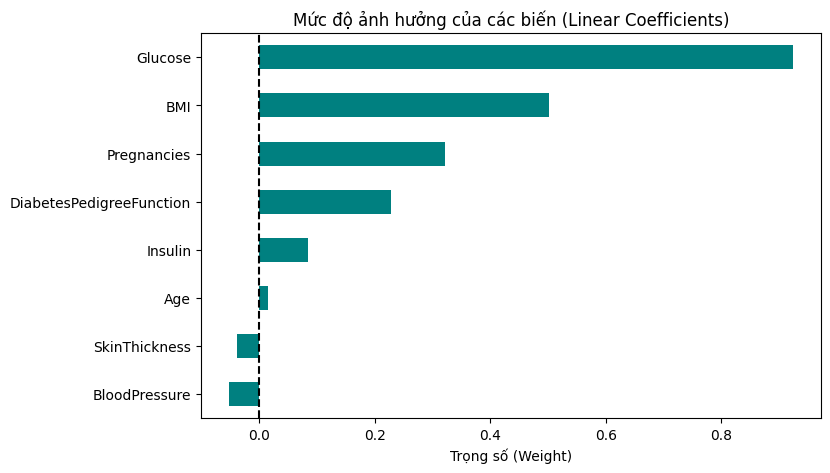

In [47]:
# Biểu đồ mức độ ảnh hưởng
plt.figure(figsize=(8, 5))
coefs.sort_values().plot(kind='barh', color='teal')
plt.title('Mức độ ảnh hưởng của các biến (Linear Coefficients)')
plt.xlabel('Trọng số (Weight)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

# **CẢI THIỆN VÀ TỐI ƯU HÓA MÔ HÌNH**

##**5.1. Đặt vấn đề: Tối ưu hóa Recall trong mô hình SVM**

**Mục tiêu cần tối ưu:**
Mục tiêu chính của bài toán chẩn đoán này là giảm thiểu rủi ro y tế bằng cách đảm bảo mô hình có khả năng phát hiện tối đa các trường hợp bệnh nhân thực tế. Điều này đòi hỏi phải tối ưu hóa chỉ số Recall (Độ nhạy).

**Hiệu suất Mô hình Cơ sở (Baseline):**
Mô hình SVM tuyến tính cơ sở (Linear SVM) ban đầu cho thấy hiệu suất chưa đạt yêu cầu, đặc biệt đối với lớp **Có bệnh (Lớp 1)**. Cụ thể:
*   Accuracy tổng thể: 71%
*   Recall: 46% - Rất thấp. Mô hình bỏ sót 54% (29/54) bệnh nhân thực tế.
*   Precision: 61%

**Vấn đề cốt lõi:** Sự mất cân bằng giữa các lớp trong dữ liệu đã khiến mô hình
bị thiên vị (bias) về phía lớp đa số (Không bệnh), dẫn đến lỗi False Negative (FN) cao, không phù hợp cho ứng dụng y tế.




###**5.2. Giải pháp cải thiện**

####**Tinh chỉnh mô hình (Cân bằng lớp và kernal RBF)**

In [48]:
# Điều chỉnh Trọng số Lớp
svc_balanced = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Huấn luyện
svc_balanced.fit(X_train_scaled, y_train)

# Dự đoán và đánh giá
y_pred_balanced = svc_balanced.predict(X_test_scaled)
print("Kết quả sau khi dùng class_weight='balanced':")
print(classification_report(y_test, y_pred_balanced))

Kết quả sau khi dùng class_weight='balanced':
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       100
           1       0.63      0.76      0.69        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.78      0.76      0.76       154



- Recall tăng vọt từ 0.46 lên 0.76 (Tăng 30 điểm phần trăm). Điều này có nghĩa là khả năng bỏ sót bệnh nhân đã giảm mạnh từ 54% xuống chỉ còn 24%.
- Precision tăng nhẹ lên 0.63 (khi mô hình dự đoán có bệnh, nó đúng 63% số lần).

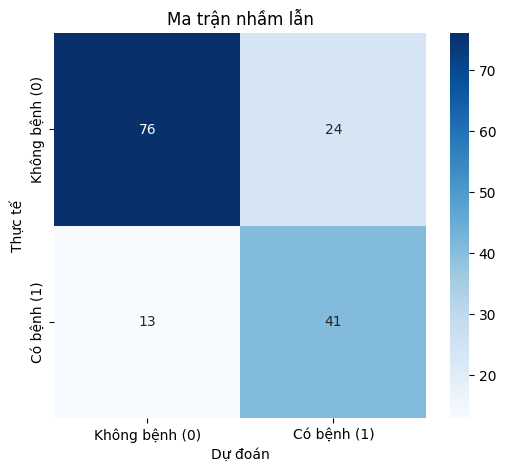

In [49]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'])
plt.title('Ma trận nhầm lẫn')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

####**Tối ưu hoá siêu tham số**
Mô hình tiếp tục được tối ưu hóa bằng GridSearchCV với mục tiêu tìm ra siêu tham số tốt nhất. Để tránh tình trạng mô hình bị thiên vị quá mức như khi sử dụng scoring='recall', dùng scoring='f1' (tìm mô hình cân bằng tốt nhất).

In [50]:
# Định nghĩa phạm vi tham số
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000, 10000],
    'gamma': [10, 1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

# Khởi tạo GridSearchCV, đặt scoring='f1'
grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=2, scoring='f1', cv=5)

# 3. Huấn luyện
grid.fit(X_train_scaled, y_train)

# 4. In ra tham số tốt nhất
print(f"Tham số tốt nhất tìm được: {grid.best_params_}")

# 5. Đánh giá mô hình tốt nhất
y_pred_tuned = grid.predict(X_test_scaled)
print("\nKết quả của mô hình SVM Tinh chỉnh tốt nhất:")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END C=0.01, class_weight=balanced, gamma=10, kernel=rbf; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, gamma=10, kernel=rbf; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, gamma=10, kernel=rbf; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, gamma=10, kernel=rbf; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, gamma=10, kernel=rbf; total time=   0.0s
[CV] END .C=0.01, class_weight=balanced, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .C=0.01, class_weight=balanced, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .C=0.01, class_weight=balanced, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .C=0.01, class_weight=balanced, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .C=0.01, class_weight=balanced, gamma=1, kernel=rbf; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, gamma=

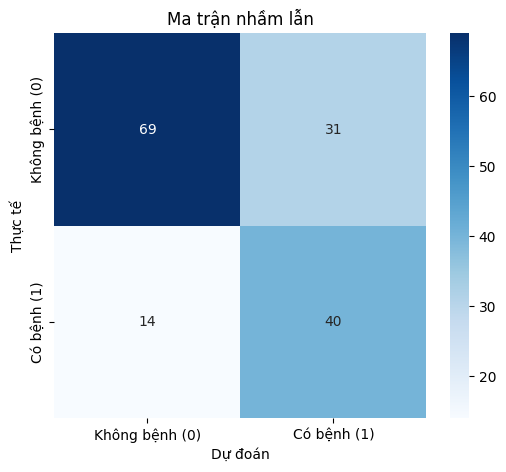

In [51]:
# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'])
plt.title('Ma trận nhầm lẫn')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

###**Điều Chỉnh Ngưỡng Quyết Định**

Ngoài việc tối ưu hóa siêu tham số, còn tiến hành điều chỉnh Ngưỡng Quyết định (Decision Threshold) trên mô hình. Mục đích là để đẩy Precision lên ngưỡng 0.70. Tuy nhiên, các thử nghiệm cho thấy việc tăng ngưỡng (lên 0.2, 0.4, 0.6,...) chỉ làm giảm Recall đáng kể mà không thể đạt được Precision 0.70. Kết quả này chứng minh rằng Precision tối đa mà thuật toán SVM có thể đạt được nằm dưới 0.70.

In [52]:
# Thử nghiệm ngưỡng mới (0.2, 0.4, 0.6) để đat ngưỡng Precision 70% trên mô hình B1
y_scores = svc_balanced.decision_function(X_test_scaled)

new_threshold = 0.6
y_pred_new_threshold = (y_scores > new_threshold).astype(int)

print(f"Kết quả với ngưỡng = {new_threshold}:")
print(classification_report(y_test, y_pred_new_threshold))

Kết quả với ngưỡng = 0.6:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



**Kết quả**:
- Precision không tăng, thậm chí chỉ thay đổi rất ít (luôn ở mức 0.63-0.64): Mặc dù đã tăng ngưỡng (từ 0.0 lên 0.6), Precision lại không cải thiện đáng kể.
 - Recall giảm mạnh: Việc tăng ngưỡng khiến mô hình trở nên quá thận trọng. Recall giảm từ 0.76 xuống 0.50. Điều này làm tăng số lượng bệnh nhân bị bỏ sót

##**5.3. Hiệu Quả Cải Thiện**

#####**Kết luận về mô hình tối ưu**
* Mô hình Cân bằng lớp cho hiệu suất tốt nhất:

  *   **Thành công lớn nhất:** Recall cho Lớp 1 tăng vọt từ 0.46 lên 0.76 Điều này giúp giảm số lượng bệnh nhân bị bỏ sót (FN) từ 29 xuống chỉ còn 13 trường hợp.
  *   **Đánh đổi và Lựa chọn:** Mặc dù không đạt được mục tiêu Precision 0.70 (khi thử điều chỉnh ngưỡng), mô hình Cân bằng Lớp vẫn được chọn vì nó cho Recall cao nhất và đạt được sự cân bằng mạnh mẽ nhất về các chỉ số hiệu suất tổng thể (Accuracy và F1-score cao).



# **SO SÁNH THUẬT TOÁN (SVM vs. Logistics Regression)**


# **6.1.1. Xây dựng mô hình với thuật toán Logistic Regression**

In [53]:
X = df.drop('Outcome', axis=1) #X: Chứa các thông tin đầu vào (Số lần mang thai, Glucose,...)
y = df['Outcome'] # Y: Chứa đáp án (Có bệnh/Không bệnh)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
feature_names = X.columns

# Mã hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
# Khởi tạo mô hình
# Cho max_iter=2000 để đảm bảo thuật toán hội tụ
lr_baseline = LogisticRegression(random_state=42, class_weight='balanced', max_iter=2000)
# Huấn luyện
lr_baseline.fit(X_train_scaled, y_train)

# Dự đoán
y_pred_lr_base = lr_baseline.predict(X_test_scaled)

# In báo cáo nhanh
print(classification_report(y_test, y_pred_lr_base))


              precision    recall  f1-score   support

           0       0.83      0.71      0.76       100
           1       0.57      0.72      0.64        54

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.72       154



# **Tinh chỉnh mô hình (thông qua Grid Search)**

In [55]:
# Thiết lập không gian tham số cần tìm kiếm
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Độ mạnh của Regularization, C là tham số nghịch đảo của điểm chuẩn
    'solver': ['liblinear', 'lbfgs'],     # Thuật toán tối ưu
    'class_weight': ['balanced']          # Luôn giữ cân bằng trọng số
}

In [56]:
# Khởi tạo GridSearchCV
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=2000),
                       param_grid_lr,
                       refit=True,
                       verbose=1,
                       scoring='recall', # Ưu tiên tìm mô hình có độ nhạy cao nhất
                       cv=5) # K-fold Cross Validation 5 lần



In [57]:
# Huấn luyện tìm tham số tốt nhất
grid_lr.fit(X_train_scaled, y_train)

# Lấy mô hình tốt nhất ra
best_lr_model = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test_scaled)
print(f"\nTham số tốt nhất tìm được: {grid_lr.best_params_}")
print("\n--- Báo cáo phân loại (LR Tuned) ---")
print(classification_report(y_test, y_pred_lr_tuned))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tham số tốt nhất tìm được: {'C': 0.001, 'class_weight': 'balanced', 'solver': 'liblinear'}

--- Báo cáo phân loại (LR Tuned) ---
              precision    recall  f1-score   support

           0       0.84      0.64      0.73       100
           1       0.54      0.78      0.64        54

    accuracy                           0.69       154
   macro avg       0.69      0.71      0.68       154
weighted avg       0.74      0.69      0.70       154



#####**Kết luận về mô hình tối ưu**
  *   **Thành công lớn nhất:** Recall cho Lớp 1 tăng vọt từ 0.64 lên 0.78
  *   **Đánh đổi và Lựa chọn:** Accuracy giảm đi từ 0.76 xuống 0.69 nhưng mô hình lại trở nên tốt hơn. Do tham số class_weight='balanced', mô hình chấp nhận "hy sinh" việc đoán đúng những người khỏe mạnh (Lớp 0) để tập trung "bắt" những người có bệnh (Lớp 1). Do đó, số lượng báo động giả tăng lên, kéo Precision và Accuracy xuống, nhưng Recall lại tăng.
  *   **Phân tích tham số tối ưu tìm được:** Giá trị C rất nhỏ (0.001). Điều này có nghĩa là mô hình đang bị Regularization (Phạt) rất mạnh. Nó chấp nhận sai số trên tập train lớn hơn để đổi lấy một đường biên phân loại đơn giản, tổng quát hơn, tránh Overfitting.




**SO SÁNH HAI MÔ HÌNH**

In [58]:
#So sánh
try:
    y_pred_svm_tuned = svc_balanced.predict(X_test_scaled)
    # Lấy điểm quyết định để vẽ ROC (SVM không mặc định ra xác suất)
    y_score_svm = svc_balanced.decision_function(X_test_scaled)
except NameError:
    print("Lỗi: Không tìm thấy biến 'svc_balanced'. Hãy chạy phần SVM trước.")
    y_pred_svm_tuned = y_test # Placeholder để code không crash
    y_score_svm = np.zeros(len(y_test))

In [59]:
# Lấy xác suất từ Logistic Regression Tuned
y_score_lr = best_lr_model.predict_proba(X_test_scaled)[:, 1]

# Tạo bảng dữ liệu so sánh
models_comparison = [
    ('Tuned SVM (RBF)', y_pred_svm_tuned, y_score_svm, 'decision_function'),
    ('Tuned Logistic Regression', y_pred_lr_tuned, y_score_lr, 'proba')
]

results = []

for name, preds, scores, score_type in models_comparison:
    # Tính toán các chỉ số
    if score_type == 'decision_function':
        auc_score = roc_auc_score(y_test, scores)
    else:
        auc_score = roc_auc_score(y_test, scores)

    results.append({
        'Mô hình': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Recall (Lớp 1)': recall_score(y_test, preds, pos_label=1),
        'Precision (Lớp 1)': precision_score(y_test, preds, pos_label=1),
        'F1-Score': f1_score(y_test, preds, pos_label=1),
        'AUC': auc_score
    })

In [60]:
# Hiển thị bảng kết quả
df_results = pd.DataFrame(results)
print("\nBẢNG SO SÁNH HIỆU SUẤT:")
display(df_results.style.highlight_max(axis=0, color='lightgreen'))


BẢNG SO SÁNH HIỆU SUẤT:


,Mô hình,Accuracy,Recall (Lớp 1),Precision (Lớp 1),F1-Score,AUC
0,Tuned SVM (RBF),0.759740,0.759259,0.630769,0.689076,0.822593
1,Tuned Logistic Regression,0.688312,0.777778,0.538462,0.636364,0.785556


#####**Sau khi tinh chỉnh cả hai mô hình, nhận thấy:**
  *   **Logistic Regression:** đạt được Recall cao nhất (0.78) nhờ cơ chế cân bằng trọng số mạnh, nhưng mô hình này mắc lỗi "Báo động giả" (False Positive) quá nhiều, kéo Precision xuống thấp (0.54) và Accuracy chỉ đạt 69%
  *   **SVM:** đã chứng minh được sức mạnh vượt trội khi xử lý dữ liệu phức tạp. Mô hình đạt Recall rất tốt (0.76 - tiệm cận Logistic) nhưng vẫn duy trì được Precision và Accuracy cao hơn hẳn.

#####**Giảng giải mô hình**: Trục Tung: True Positive Rate, Trục Hoành: False Positive Rate
 - Trục Tung càng cao càng tốt
 - Trục Hoành càng thấp, càng về trái càng tốt

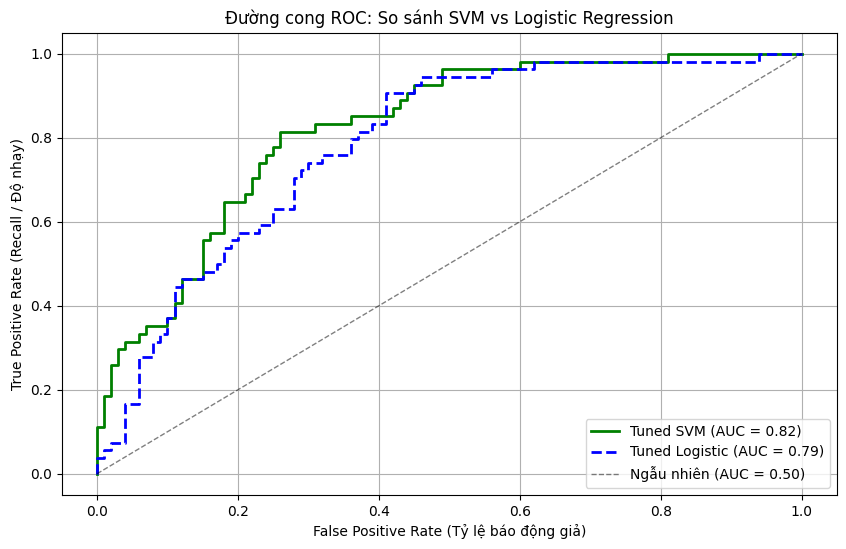

In [61]:
# VẼ BIỂU ĐỒ ROC
plt.figure(figsize=(10, 6))

# Vẽ đường SVM (Màu xanh lá)
# Kiểm tra xem có dữ liệu không trước khi vẽ
if 'y_score_svm' in locals() and len(y_score_svm) > 0:
    fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
    auc_svm = roc_auc_score(y_test, y_score_svm)
    plt.plot(fpr_svm, tpr_svm,
             label=f'Tuned SVM (AUC = {auc_svm:.2f})',
             color='green', lw=2)
else:
    print("Cảnh báo: Không có dữ liệu SVM để vẽ.")

# Vẽ đường Logistic Regression (Màu xanh dương)
if 'y_score_lr' in locals() and len(y_score_lr) > 0:
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
    auc_lr = roc_auc_score(y_test, y_score_lr)
    plt.plot(fpr_lr, tpr_lr,
             label=f'Tuned Logistic (AUC = {auc_lr:.2f})',
             color='blue', lw=2, linestyle='--')
else:
    print("Cảnh báo: Không có dữ liệu Logistic để vẽ.")

# 3. Vẽ đường tham chiếu (Ngẫu nhiên)
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Ngẫu nhiên (AUC = 0.50)')

# Trang trí
plt.xlabel('False Positive Rate (Tỷ lệ báo động giả)')
plt.ylabel('True Positive Rate (Recall / Độ nhạy)')
plt.title('Đường cong ROC: So sánh SVM vs Logistic Regression')
plt.grid(True)

# Hiển thị chú thích
# Lệnh này sẽ tìm các tham số 'label' ở trên để hiển thị
plt.legend(loc='lower right')

plt.show()

#####**Nhận xét:**
  Nhìn vào biểu đồ ROC, cả hai mô hình đều uốn cong về phía góc trái trên, chứng tỏ chúng đều học tốt. Tuy nhiên, đường SVM (Màu xanh lá) bao trùm lên đường Logistic (Màu xanh dương) ở hầu hết các ngưỡng. Điều này khẳng định SVM không chỉ có Recall tốt mà khả năng phân loại tổng quát (AUC) cũng vượt trội hơn, xứng đáng là mô hình được lựa chọn cuối cùng.